In [36]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt


In [6]:
df = pd.read_csv("Amazon Sale Report.csv")
df.head()


C:\Users\Adhyay\AppData\Local\Temp\ipykernel_4664\660934291.py:1: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Amazon Sale Report.csv")


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [8]:
conn = sqlite3.connect(":memory:")  # temporary DB


In [9]:
df.to_sql("sales", conn, index=False, if_exists="replace")


128975

In [13]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("-", "_")
)

df.columns


Index(['index', 'order_id', 'date', 'status', 'fulfilment', 'sales_channel',
       'ship_service_level', 'style', 'sku', 'category', 'size', 'asin',
       'courier_status', 'qty', 'currency', 'amount', 'ship_city',
       'ship_state', 'ship_postal_code', 'ship_country', 'promotion_ids',
       'b2b', 'fulfilled_by', 'unnamed:_22'],
      dtype='object')

In [14]:
df = df.drop(columns=["unnamed:_22", "index"], errors="ignore")


In [18]:
import sqlite3
conn = sqlite3.connect(":memory:")
df.to_sql("sales", conn, index=False, if_exists="replace")

128975

In [ ]:
query = """
SELECT 
    substr(date, 1, 7) AS month,
    SUM(CAST(amount AS REAL)) AS monthly_revenue
FROM sales
GROUP BY month
ORDER BY month;
"""

pd.read_sql(query, conn)




NameError: name 'plt' is not defined

In [24]:
query = """
SELECT 
    SUM(CAST(amount AS REAL)) AS total_revenue
FROM sales;
"""

pd.read_sql(query, conn)


,total_revenue
0,78592678.3


In [25]:
queries = [
    """
    SELECT 
        substr(date, 1, 7) AS month,
        SUM(CAST(amount AS REAL)) AS monthly_revenue
    FROM sales
    GROUP BY month
    ORDER BY month;
    """,
    """
    SELECT 
        SUM(CAST(amount AS REAL)) AS total_revenue
    FROM sales;
    """
]

for q in queries:
    display(pd.read_sql(q, conn))


,month,monthly_revenue
0,03-31-2,101683.85
1,04-01-2,865478.60
2,04-02-2,913101.53
3,04-03-2,1011763.38
4,04-04-2,882059.17
...,...,...
86,06-25-2,654234.58
87,06-26-2,773610.02
88,06-27-2,714124.67
89,06-28-2,772085.53


,total_revenue
0,78592678.3


In [26]:
query = """
SELECT 
    status,
    COUNT(order_id) AS total_orders
FROM sales
GROUP BY status
ORDER BY total_orders DESC;
"""
pd.read_sql(query, conn)


,status,total_orders
0,Shipped,77804
1,Shipped - Delivered to Buyer,28769
2,Cancelled,18332
3,Shipped - Returned to Seller,1953
4,Shipped - Picked Up,973
5,Pending,658
6,Pending - Waiting for Pick Up,281
7,Shipped - Returning to Seller,145
8,Shipped - Out for Delivery,35
9,Shipped - Rejected by Buyer,11


In [27]:
query = """
SELECT 
    category,
    SUM(CAST(amount AS REAL)) AS category_revenue
FROM sales
WHERE amount IS NOT NULL
GROUP BY category
ORDER BY category_revenue DESC;
"""
pd.read_sql(query, conn)


,category,category_revenue
0,Set,39204124.03
1,kurta,21299546.70
2,Western Dress,11216072.69
3,Top,5347792.30
4,Ethnic Dress,791217.66
5,Blouse,458408.18
6,Bottom,150667.98
7,Saree,123933.76
8,Dupatta,915.00


In [28]:
query = """
SELECT 
    sku,
    SUM(qty) AS total_units_sold
FROM sales
GROUP BY sku
ORDER BY total_units_sold DESC
LIMIT 10;
"""
pd.read_sql(query, conn)


,sku,total_units_sold
0,JNE3797-KR-L,661
1,JNE3797-KR-M,561
2,JNE3797-KR-S,503
3,JNE3405-KR-L,485
4,J0230-SKD-M,468
5,J0230-SKD-S,421
6,JNE3797-KR-XL,415
7,JNE3405-KR-S,399
8,JNE3797-KR-XS,386
9,SET268-KR-NP-XL,373


In [29]:
query = """
SELECT 
    ship_state,
    SUM(CAST(amount AS REAL)) AS state_revenue
FROM sales
WHERE amount IS NOT NULL
GROUP BY ship_state
ORDER BY state_revenue DESC;
"""
pd.read_sql(query, conn)


,ship_state,state_revenue
0,MAHARASHTRA,13335534.14
1,KARNATAKA,10481114.37
2,TELANGANA,6916615.65
3,UTTAR PRADESH,6816642.08
4,TAMIL NADU,6515650.11
...,...,...
64,Pondicherry,529.00
65,rajsthan,521.00
66,AR,493.00
67,Rajsthan,443.00


In [30]:
query = """
SELECT 
    sales_channel,
    SUM(CAST(amount AS REAL)) AS channel_revenue
FROM sales
WHERE amount IS NOT NULL
GROUP BY sales_channel
ORDER BY channel_revenue DESC;
"""
pd.read_sql(query, conn)


,sales_channel,channel_revenue
0,Amazon.in,78592678.3


In [31]:
query = """
SELECT 
    b2b,
    SUM(CAST(amount AS REAL)) AS revenue
FROM sales
WHERE amount IS NOT NULL
GROUP BY b2b;
"""
pd.read_sql(query, conn)


,b2b,revenue
0,0,78001457.51
1,1,591220.79


In [32]:
query = """
SELECT 
    courier_status,
    COUNT(order_id) AS order_count
FROM sales
GROUP BY courier_status
ORDER BY order_count DESC;
"""
pd.read_sql(query, conn)


,courier_status,order_count
0,Shipped,109487
1,None,6872
2,Unshipped,6681
3,Cancelled,5935


In [33]:
query = """
SELECT 
    category,
    SUM(CAST(amount AS REAL)) AS revenue
FROM sales
WHERE amount IS NOT NULL
GROUP BY category
ORDER BY revenue ASC
LIMIT 10;
"""
pd.read_sql(query, conn)


,category,revenue
0,Dupatta,915.00
1,Saree,123933.76
2,Bottom,150667.98
3,Blouse,458408.18
4,Ethnic Dress,791217.66
5,Top,5347792.30
6,Western Dress,11216072.69
7,kurta,21299546.70
8,Set,39204124.03


In [47]:
df_monthly


,month,monthly_revenue
0,03-31-2,101683.85
1,04-01-2,865478.60
2,04-02-2,913101.53
3,04-03-2,1011763.38
4,04-04-2,882059.17
...,...,...
86,06-25-2,654234.58
87,06-26-2,773610.02
88,06-27-2,714124.67
89,06-28-2,772085.53


In [48]:
query = """
SELECT 
    strftime('%Y-%m', date) AS month,
    SUM(CAST(amount AS REAL)) AS monthly_revenue
FROM sales
WHERE amount IS NOT NULL
  AND date IS NOT NULL
GROUP BY month
ORDER BY month;
"""


In [49]:
df_monthly = pd.read_sql(query, conn)
df_monthly


,month,monthly_revenue
0,None,78592678.3


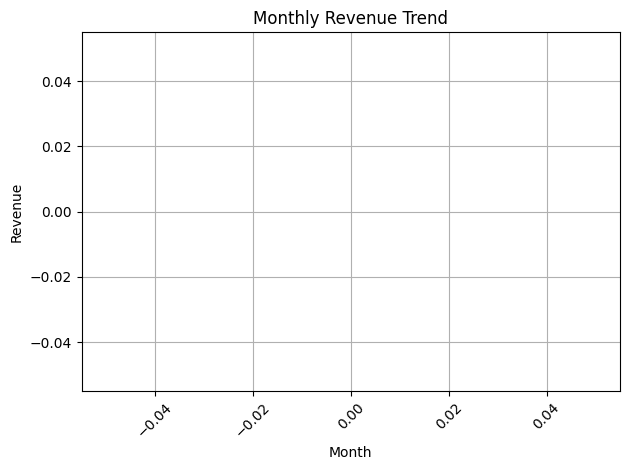

In [50]:
plt.figure()
plt.plot(df_monthly["month"], df_monthly["monthly_revenue"], marker='o')
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")
plt.grid(True)
plt.tight_layout()
plt.show()


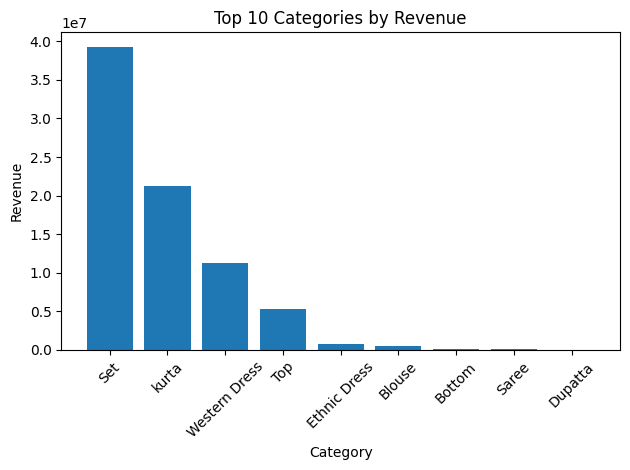

In [38]:
query = """
SELECT 
    category,
    SUM(CAST(amount AS REAL)) AS category_revenue
FROM sales
WHERE amount IS NOT NULL
GROUP BY category
ORDER BY category_revenue DESC
LIMIT 10;
"""

df_category = pd.read_sql(query, conn)

plt.figure()
plt.bar(df_category["category"], df_category["category_revenue"])
plt.xticks(rotation=45)
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.title("Top 10 Categories by Revenue")
plt.tight_layout()
plt.show()


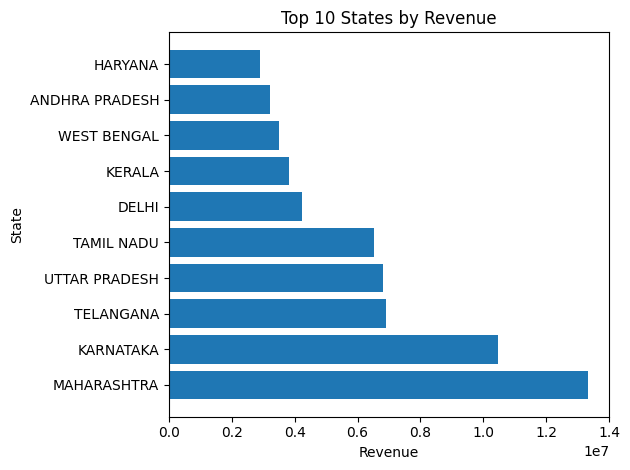

In [39]:
query = """
SELECT 
    ship_state,
    SUM(CAST(amount AS REAL)) AS state_revenue
FROM sales
WHERE amount IS NOT NULL
GROUP BY ship_state
ORDER BY state_revenue DESC
LIMIT 10;
"""

df_state = pd.read_sql(query, conn)

plt.figure()
plt.barh(df_state["ship_state"], df_state["state_revenue"])
plt.xlabel("Revenue")
plt.ylabel("State")
plt.title("Top 10 States by Revenue")
plt.tight_layout()
plt.show()


In [46]:
df_status

,status,total_orders
0,Cancelled,18332
1,Pending,658
2,Pending - Waiting for Pick Up,281
3,Shipped,77804
4,Shipped - Damaged,1
5,Shipped - Delivered to Buyer,28769
6,Shipped - Lost in Transit,5
7,Shipped - Out for Delivery,35
8,Shipped - Picked Up,973
9,Shipped - Rejected by Buyer,11


In [43]:
query = """
SELECT status, COUNT(*) AS cnt
FROM sales
GROUP BY status
ORDER BY cnt DESC;
"""
pd.read_sql(query, conn)


,status,cnt
0,Shipped,77804
1,Shipped - Delivered to Buyer,28769
2,Cancelled,18332
3,Shipped - Returned to Seller,1953
4,Shipped - Picked Up,973
5,Pending,658
6,Pending - Waiting for Pick Up,281
7,Shipped - Returning to Seller,145
8,Shipped - Out for Delivery,35
9,Shipped - Rejected by Buyer,11


In [44]:
query = """
SELECT 
    CASE
        WHEN lower(status) LIKE '%delivered%' THEN 'Delivered'
        WHEN lower(status) LIKE '%cancel%' THEN 'Cancelled'
        ELSE 'Other'
    END AS order_status,
    COUNT(order_id) AS total_orders
FROM sales
GROUP BY order_status;
"""

df_status_clean = pd.read_sql(query, conn)
df_status_clean


,order_status,total_orders
0,Cancelled,18332
1,Delivered,28769
2,Other,81874


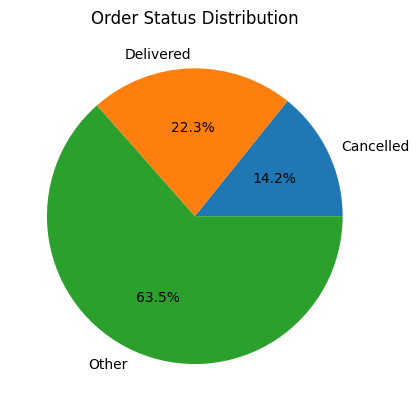

In [45]:
plt.figure()
plt.pie(
    df_status_clean["total_orders"],
    labels=df_status_clean["order_status"],
    autopct="%1.1f%%"
)
plt.title("Order Status Distribution")
plt.show()


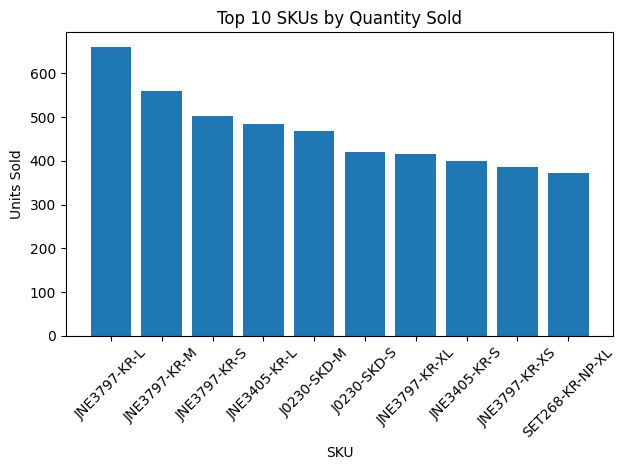

In [41]:
query = """
SELECT 
    sku,
    SUM(qty) AS total_units_sold
FROM sales
GROUP BY sku
ORDER BY total_units_sold DESC
LIMIT 10;
"""

df_sku = pd.read_sql(query, conn)

plt.figure()
plt.bar(df_sku["sku"], df_sku["total_units_sold"])
plt.xticks(rotation=45)
plt.xlabel("SKU")
plt.ylabel("Units Sold")
plt.title("Top 10 SKUs by Quantity Sold")
plt.tight_layout()
plt.show()


In [52]:
query = """
SELECT 
    strftime('%Y-%m', date) AS month,
    SUM(CAST(amount AS REAL)) AS monthly_revenue
FROM sales
WHERE amount IS NOT NULL
  AND date IS NOT NULL
  AND lower(status) NOT LIKE '%cancel%'
GROUP BY month
ORDER BY month;
"""
